<a href="https://colab.research.google.com/github/ishwaryac20-prog/Social_Media_Engagement_Analytics_Python/blob/main/Social_Media_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Social Media Data Analysis

## **Introduction**

Social media platforms generate large volumes of data through user activities such as likes, comments, shares, impressions, followers, watch time, and engagement. Analyzing this data helps identify patterns in user behavior, content performance, and audience engagement.

In this assignment, **Python** is used to perform an end-to-end analysis of a Social Media dataset. The project covers **data import, data cleaning, exploratory data analysis, data wrangling, statistical analysis, and data visualization** using libraries such as **Pandas, NumPy, Matplotlib, Seaborn, and Plotly**.

The main objective is to transform raw social media data into meaningful insights about **content performance, audience engagement, user trends, posting patterns, device usage, and sentiment**. The assignment demonstrates how Python-based data analytics techniques can be applied to understand and interpret real-world social media data.

## **📌 Assignment Instructions**

1. 📥 Upload the CSV dataset when prompted.
2. ▶️ Run all cells sequentially from Task 1 through Final Insights.
3. 🔎 Review the detected column mapping before continuing.
4. 🧹 Verify the cleaning, transformation, and statistical outputs.
5. 📊 Review all visualizations and interactive Plotly charts.
6. 💡 Use the Final Insights section to interpret the analysis results.
7. 💾 Save the completed notebook as an `.ipynb` file for submission.


## 🛠️ Setup & Library Import

In [1]:
# Install/import the libraries required for the assignment
!pip -q install plotly openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import re
from IPython.display import display
from google.colab import files

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme()
print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


# 📥 TASK 1 — DATA IMPORT & SETUP

## 1.1 Import CSV using Pandas

In [2]:
# Upload the CSV file
uploaded = files.upload()

csv_files = [name for name in uploaded.keys() if name.lower().endswith('.csv')]

if not csv_files:
    raise ValueError("❌ No CSV file was uploaded. Please upload the assignment CSV file.")

file_name = csv_files[0]
df = pd.read_csv(file_name)

print(f"✅ Dataset imported: {file_name}")
print(f"📌 Rows: {df.shape[0]:,}")
print(f"📌 Columns: {df.shape[1]:,}")

display(df.head())


Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv
✅ Dataset imported: social_media_engagement_5000.csv
📌 Rows: 5,000
📌 Columns: 19


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.00,Female,Brazil,496713,image,fitness,"7,011.00",354.00,"1,157.00",5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.19
1,10860,33.00,Male,Brazil,157326,reel,food,"11,750.00","2,606.00","1,807.00",5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.20
2,86820,32.00,Female,UK,109864,text,food,"4,862.00",344.00,955.00,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.14
3,64886,51.00,Other,France,848877,text,fitness,"5,350.00","1,083.00","1,049.00",229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.11
4,16265,34.00,Other,UK,449706,image,fitness,"12,682.00","2,735.00","1,300.00",4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.78


## 1.2 Check Data Types

In [3]:
print("📋 Data Types Before Conversion")
display(pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str).values,
    'Missing Values': df.isna().sum().values
}))


📋 Data Types Before Conversion


,Column,Data Type,Missing Values
0,user_id,int64,0
1,age,float64,150
2,gender,object,150
3,country,object,0
4,post_id,int64,0
5,post_type,object,0
6,post_category,object,0
7,likes,float64,150
8,comments,float64,150
9,shares,float64,150


## 1.3 Detect and Convert Date Columns to Datetime

In [53]:
# 🕐 Convert only genuine date/time fields to datetime.
# IMPORTANT: fields such as watch_time_sec/watch_time_minutes remain numeric.

date_candidates = [
    'posted_at', 'post_date', 'date', 'created_at', 'created_date',
    'publish_date', 'published_at', 'timestamp', 'datetime',
    'post_datetime', 'created_datetime', 'publish_datetime'
]

time_candidates = [
    'post_time', 'time', 'created_time', 'publish_time', 'posted_time'
]

detected_date_cols = [
    c for c in df.columns
    if c.lower().strip() in date_candidates
]

for col in detected_date_cols:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce',
        dayfirst=True
    )

# Explicitly keep duration/watch-time fields numeric
duration_candidates = [
    c for c in df.columns
    if any(token in c.lower() for token in [
        'watch_time', 'watchtime', 'watch_duration',
        'view_duration', 'watch_seconds', 'watch_minutes'
    ])
]

for col in duration_candidates:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("📅 Date/time columns converted:", detected_date_cols if detected_date_cols else "None detected")
print("⏱️ Duration/watch-time columns kept numeric:", duration_candidates if duration_candidates else "None detected")


📅 Date/time columns converted: ['posted_at']
⏱️ Duration/watch-time columns kept numeric: ['watch_time_sec']


## 1.4 Standardize Column Names & Detect Common Fields

In [5]:
# Clean column names for easier analysis
original_columns = df.columns.tolist()

df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace(r'[^a-z0-9]+', '_', regex=True)
      .str.strip('_')
)

print("Original columns:")
print(original_columns)
print("\nStandardized columns:")
print(df.columns.tolist())

# Flexible and robust column detection.
# Exact aliases are checked first, followed by semantic/partial matching.
ALIASES = {
    'likes': [
        'likes', 'like', 'like_count', 'likes_count', 'total_likes',
        'num_likes', 'likes_total'
    ],
    'comments': [
        'comments', 'comment', 'comment_count', 'comments_count',
        'total_comments', 'num_comments'
    ],
    'shares': [
        'shares', 'share', 'share_count', 'shares_count',
        'total_shares', 'num_shares'
    ],
    'watch_time': [
        'watch_time', 'watchtime', 'watch_time_sec', 'watchtime_sec',
        'watch_time_seconds', 'watch_seconds', 'watch_duration',
        'watch_duration_sec', 'watch_duration_seconds',
        'watch_time_minutes', 'watch_minutes', 'view_duration'
    ],
    'engagement_rate': [
        'engagement_rate', 'engagementrate', 'engagement_rate_pct',
        'engagement_rate_percent', 'engagement_percentage',
        'engagement_percent', 'engagement'
    ],
    'followers': [
        'followers', 'follower', 'follower_count', 'followers_count',
        'total_followers', 'num_followers'
    ],
    'impressions': [
        'impressions', 'impression', 'impression_count',
        'impressions_count', 'total_impressions', 'reach',
        'reach_count', 'views', 'view_count', 'views_count'
    ],
    'post_type': [
        'post_type', 'posttype', 'content_type', 'media_type',
        'post_format', 'format'
    ],
    'category': [
        'category', 'content_category', 'post_category',
        'content_type_category', 'content_category_name'
    ],
    'country': [
        'country', 'country_name', 'location_country', 'user_country'
    ],
    'sentiment': [
        'sentiment', 'sentiment_label', 'sentiment_type',
        'sentiment_score_label'
    ],
    'gender': ['gender', 'sex'],
    'age': ['age', 'user_age', 'user_age_years'],
    'verified': [
        'verified', 'is_verified', 'verified_account',
        'account_verified', 'verification_status'
    ],
    'device': [
        'device', 'device_type', 'platform_device',
        'user_device', 'device_used', 'platform'
    ],
    'hashtags': [
        'hashtags', 'hashtag', 'tags', 'hashtags_text',
        'hashtag_text'
    ],
    'post_date': [
        'posted_at', 'post_date', 'date', 'created_at',
        'created_date', 'publish_date', 'published_at',
        'timestamp', 'datetime', 'post_datetime'
    ],
    'post_time': [
        'post_time', 'time', 'created_time',
        'publish_time', 'posted_time'
    ]
}

def normalize_name(x):
    return re.sub(r'[^a-z0-9]+', '_', str(x).lower()).strip('_')

def find_col(canonical):
    aliases = [normalize_name(x) for x in ALIASES.get(canonical, [])]

    # 1. Exact match
    for candidate in aliases:
        if candidate in df.columns:
            return candidate

    # 2. Strong semantic matching
    for col in df.columns:
        c = normalize_name(col)

        if canonical == 'watch_time' and (
            ('watch' in c and ('time' in c or 'duration' in c or 'sec' in c or 'minute' in c))
            or 'view_duration' in c
        ):
            return col

        if canonical == 'engagement_rate' and 'engagement' in c and (
            'rate' in c or 'percent' in c or 'pct' in c
        ):
            return col

        if canonical == 'impressions' and (
            'impression' in c or c in ['reach', 'views', 'view_count']
        ):
            return col

        if canonical in ['likes', 'comments', 'shares'] and canonical.rstrip('s') in c:
            return col

        if canonical == 'post_date' and (
            c.endswith('_at') or 'date' in c or 'datetime' in c or 'timestamp' in c
        ):
            # Exclude numeric duration fields
            if not any(x in c for x in ['watch', 'duration', 'seconds', 'minutes']):
                return col

        if canonical == 'device' and ('device' in c or c == 'platform'):
            return col

    return None

column_map = {key: find_col(key) for key in ALIASES}

print("\n🔎 Detected fields:")
display(pd.DataFrame({
    'Standard Field': list(column_map.keys()),
    'Detected Dataset Column': list(column_map.values())
}))

# Convenient variables used throughout the notebook
likes_col = column_map['likes']
comments_col = column_map['comments']
shares_col = column_map['shares']
watch_col = column_map['watch_time']
eng_rate_col = column_map['engagement_rate']
followers_col = column_map['followers']
impressions_col = column_map['impressions']
post_type_col = column_map['post_type']
category_col = column_map['category']
country_col = column_map['country']
sentiment_col = column_map['sentiment']
gender_col = column_map['gender']
age_col = column_map['age']
verified_col = column_map['verified']
device_col = column_map['device']
date_col = column_map['post_date']
time_col = column_map['post_time']

# Convert known numeric metrics
for col in [
    likes_col, comments_col, shares_col, watch_col,
    eng_rate_col, followers_col, impressions_col, age_col
]:
    if col and col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert genuine date field only
if date_col and date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

print("\n✅ Column detection, numeric conversion, and date handling completed.")


Original columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

Standardized columns:
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate']

🔎 Detected fields:


,Standard Field,Detected Dataset Column
0,likes,likes
1,comments,comments
2,shares,shares
3,watch_time,watch_time_sec
4,engagement_rate,engagement_rate
5,followers,follower_count
6,impressions,impression_count
7,post_type,post_type
8,category,post_category
9,country,country



✅ Column detection, numeric conversion, and date handling completed.


# 🧹 TASK 2 — DATA CLEANING

## 2.1 Detect Missing Values using `isnull()` and `isna()`

In [6]:
print("🔍 Missing-value count using isnull():")
display(df.isnull().sum().sort_values(ascending=False).to_frame('Missing_Count'))

print("\n🔍 Missing-value count using isna():")
display(df.isna().sum().sort_values(ascending=False).to_frame('Missing_Count'))

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame('Missing_Percentage'))


🔍 Missing-value count using isnull():


,Missing_Count
age,150
gender,150
comments,150
likes,150
shares,150
sentiment,150
user_id,0
post_category,0
post_type,0
post_id,0



🔍 Missing-value count using isna():


,Missing_Count
age,150
gender,150
comments,150
likes,150
shares,150
sentiment,150
user_id,0
post_category,0
post_type,0
post_id,0


,Missing_Percentage
age,3.00
gender,3.00
comments,3.00
likes,3.00
shares,3.00
sentiment,3.00
user_id,0.00
post_category,0.00
post_type,0.00
post_id,0.00


## 2.2 Handle Missing Values — `dropna()`, `fillna()`, Median/Mode, Forward/Backward Fill

In [7]:
# Work on a copy so the original imported dataset remains available
clean_df = df.copy()

# Demonstrate dropna()
dropna_demo = clean_df.dropna(how='all')
print(f"Rows before dropna(how='all): {len(clean_df):,}")
print(f"Rows after  dropna(how='all): {len(dropna_demo):,}")

# Numeric columns: median fill
numeric_cols = clean_df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    if clean_df[col].isna().any():
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Categorical columns: mode fill
categorical_cols = clean_df.select_dtypes(include=['object', 'category']).columns.tolist()
for col in categorical_cols:
    if clean_df[col].isna().any():
        mode = clean_df[col].mode(dropna=True)
        if not mode.empty:
            clean_df[col] = clean_df[col].fillna(mode.iloc[0])

# Date columns: forward-fill then backward-fill
date_cols_clean = clean_df.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns.tolist()
for col in date_cols_clean:
    clean_df[col] = clean_df[col].ffill().bfill()

print("✅ Missing values handled using:")
print("   • Median for numeric columns")
print("   • Mode for categorical columns")
print("   • Forward-fill + backward-fill for datetime columns")

remaining_missing = clean_df.isna().sum().sum()
print(f"\nRemaining missing cells: {remaining_missing:,}")


Rows before dropna(how='all): 5,000
Rows after  dropna(how='all): 5,000
✅ Missing values handled using:
   • Median for numeric columns
   • Mode for categorical columns
   • Forward-fill + backward-fill for datetime columns

Remaining missing cells: 0


## 2.3 Duplicate Handling — Identify & Remove Duplicates

In [8]:
duplicate_count = clean_df.duplicated().sum()
print(f"🔍 Duplicate rows identified: {duplicate_count:,}")

if duplicate_count > 0:
    display(clean_df[clean_df.duplicated(keep=False)].head(10))

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print(f"✅ Dataset shape after duplicate removal: {clean_df.shape}")


🔍 Duplicate rows identified: 0
✅ Dataset shape after duplicate removal: (5000, 19)


## 2.4 Data Formatting — Correct Data Types

In [9]:
# Convert detected numeric metrics to numeric
metric_fields = ['likes', 'comments', 'shares', 'watch_time',
                 'engagement_rate', 'followers', 'impressions', 'age']

for field in metric_fields:
    col = column_map.get(field)
    if col and col in clean_df.columns:
        clean_df[col] = pd.to_numeric(
            clean_df[col].astype(str).str.replace(',', '', regex=False).str.replace('%', '', regex=False),
            errors='coerce'
        )

# Re-check types
print("📋 Data types after formatting:")
display(clean_df.dtypes.to_frame('Data_Type'))


📋 Data types after formatting:


,Data_Type
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


## 2.5 Standardize Categories — Example: Gender Labels

In [10]:
def standardize_gender(value):
    if pd.isna(value):
        return np.nan
    x = str(value).strip().lower()
    mapping = {
        'm': 'Male', 'male': 'Male', 'man': 'Male',
        'f': 'Female', 'female': 'Female', 'woman': 'Female',
        'other': 'Other', 'o': 'Other',
        'non-binary': 'Other', 'nonbinary': 'Other',
        'unknown': 'Unknown'
    }
    return mapping.get(x, str(value).strip().title())

gender_col = column_map.get('gender')
if gender_col and gender_col in clean_df.columns:
    before = clean_df[gender_col].value_counts(dropna=False)
    clean_df[gender_col] = clean_df[gender_col].apply(standardize_gender)
    after = clean_df[gender_col].value_counts(dropna=False)
    print("Before standardization:")
    display(before.to_frame('Count'))
    print("After standardization:")
    display(after.to_frame('Count'))
else:
    print("⚠️ Gender column not detected; gender standardization skipped.")


Before standardization:


,Count
gender,
Male,1849
Other,1581
Female,1570


After standardization:


,Count
gender,
Male,1849
Other,1581
Female,1570


## 2.6 Correct Unrealistic Values in Likes, Comments & Shares

In [11]:
social_cols = [column_map.get(x) for x in ['likes', 'comments', 'shares']]
social_cols = [c for c in social_cols if c and c in clean_df.columns]

print("Columns checked:", social_cols)

# Negative interactions are unrealistic; convert them to NaN and fill with median.
for col in social_cols:
    invalid = (clean_df[col] < 0).sum()
    if invalid:
        print(f"⚠️ {col}: {invalid} negative values corrected.")
        clean_df.loc[clean_df[col] < 0, col] = np.nan
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())

# Basic logical consistency: comments/shares should not be negative.
# Likes/comments/shares may be highly skewed, so extreme high values are not automatically removed.
for col in social_cols:
    print(f"{col}: min={clean_df[col].min():,.2f}, max={clean_df[col].max():,.2f}")

print("✅ Unrealistic negative interaction values handled.")


Columns checked: ['likes', 'comments', 'shares']
likes: min=10.00, max=19,998.00
comments: min=0.00, max=2,999.00
shares: min=0.00, max=1,999.00
✅ Unrealistic negative interaction values handled.


## 2.7 Feature Cleaning — Extract Hashtag Count

In [12]:
hashtag_col = column_map.get('hashtags')

if hashtag_col and hashtag_col in clean_df.columns:
    def count_hashtags(value):
        if pd.isna(value):
            return 0
        text = str(value)
        # Count words beginning with #
        return len(re.findall(r'(?<!\w)#\w+', text))

    clean_df['hashtag_count'] = clean_df[hashtag_col].apply(count_hashtags)
else:
    # If the dataset has no hashtag field, create a valid zero-count feature
    clean_df['hashtag_count'] = 0
    print("⚠️ Hashtag column not detected. 'hashtag_count' created as 0.")

display(clean_df[['hashtag_count']].head())
print("Total hashtags:", int(clean_df['hashtag_count'].sum()))


,hashtag_count
0,3
1,1
2,1
3,3
4,1


Total hashtags: 9993


## 2.8 Feature Cleaning — Clean Sentiment Labels

In [13]:
sentiment_col = column_map.get('sentiment')

if sentiment_col and sentiment_col in clean_df.columns:
    def clean_sentiment(value):
        if pd.isna(value):
            return np.nan
        x = str(value).strip().lower()
        if 'positive' in x or x in ['pos', '+']:
            return 'Positive'
        if 'negative' in x or x in ['neg', '-']:
            return 'Negative'
        if 'neutral' in x or x in ['neu', '0']:
            return 'Neutral'
        return str(value).strip().title()

    clean_df[sentiment_col] = clean_df[sentiment_col].apply(clean_sentiment)
    print("Cleaned sentiment distribution:")
    display(clean_df[sentiment_col].value_counts(dropna=False).to_frame('Count'))
else:
    print("⚠️ Sentiment column not detected; sentiment cleaning skipped.")

df_clean = clean_df.copy()
print(f"\n✅ Final cleaned dataset shape: {df_clean.shape}")


Cleaned sentiment distribution:


,Count
sentiment,
Positive,2513
Neutral,1527
Negative,960



✅ Final cleaned dataset shape: (5000, 20)


# 🔎 TASK 3 — DATA EXPLORATION USING PANDAS

## 3.1 View Dataset Structure — `head()`, `tail()`, `shape`, `columns`

In [14]:
print("🔹 HEAD — First 5 Rows")
display(df_clean.head())

print("🔹 TAIL — Last 5 Rows")
display(df_clean.tail())

print("🔹 SHAPE")
print(df_clean.shape)

print("\n🔹 COLUMNS")
print(df_clean.columns.tolist())


🔹 HEAD — First 5 Rows


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.00,Female,Brazil,496713,image,fitness,"7,011.00",354.00,"1,157.00",5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.19,3
1,10860,33.00,Male,Brazil,157326,reel,food,"11,750.00","2,606.00","1,807.00",5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.20,1
2,86820,32.00,Female,UK,109864,text,food,"4,862.00",344.00,955.00,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.14,1
3,64886,51.00,Other,France,848877,text,fitness,"5,350.00","1,083.00","1,049.00",229,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.11,3
4,16265,34.00,Other,UK,449706,image,fitness,"12,682.00","2,735.00","1,300.00",4798,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.78,1


🔹 TAIL — Last 5 Rows


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.00,Male,Australia,441541,video,education,"16,210.00","2,013.00","1,837.00",6190,42977,2022-06-25,646147,False,mobile,Positive,#travel #fun,0.47,2
4996,22100,38.00,Other,UAE,677076,reel,education,"16,924.00","2,734.00","1,583.00",7764,34196,2022-11-18,584603,False,desktop,Negative,#foodie #reels,0.62,2
4997,67021,63.00,Female,USA,273595,text,travel,"13,487.00","1,497.00",167.00,7466,23680,2023-04-06,483550,False,desktop,Positive,#lifestyle #tech,0.68,2
4998,29800,13.00,Female,Germany,785644,video,fitness,"16,894.00","1,289.00","1,713.00",4991,89013,2022-05-16,183295,False,tablet,Positive,#reels #love #fitness,0.22,3
4999,73400,54.00,Other,Japan,712252,text,travel,"14,830.00",503.00,"1,798.00",3743,14234,2023-03-04,585760,False,desktop,Neutral,#foodie #lifestyle #fashion,1.20,3


🔹 SHAPE
(5000, 20)

🔹 COLUMNS
['user_id', 'age', 'gender', 'country', 'post_id', 'post_type', 'post_category', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'posted_at', 'follower_count', 'is_verified', 'device_type', 'sentiment', 'hashtags', 'engagement_rate', 'hashtag_count']


## 3.2 Check Data Types and Information — `info()` and `dtypes`

In [15]:
print("🔹 INFO")
df_clean.info()

print("\n🔹 DTYPES")
display(df_clean.dtypes.to_frame('Data_Type'))


🔹 INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified      

,Data_Type
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


## 3.3 Summary Statistics — `describe()`

In [16]:
print("📊 Descriptive Statistics for Numeric Columns")
display(df_clean.describe(include='number').T)

print("\n📋 Summary including categorical fields")
display(df_clean.describe(include='all').T)


📊 Descriptive Statistics for Numeric Columns


,count,mean,std,min,25%,50%,75%,max
user_id,"5,000.00","54,561.89","26,090.37","10,055.00","32,309.50","54,374.50","77,180.50","99,963.00"
age,"5,000.00",38.44,14.69,13.00,26.00,38.00,51.00,64.00
post_id,"5,000.00","548,042.91","260,646.96","100,068.00","322,543.50","548,077.50","771,574.50","999,455.00"
likes,"5,000.00","10,107.00","5,702.29",10.00,"5,235.00","10,105.50","14,959.00","19,998.00"
comments,"5,000.00","1,502.04",856.39,0.00,792.00,"1,497.00","2,235.25","2,999.00"
shares,"5,000.00","1,002.91",570.86,0.00,511.00,"1,012.00","1,483.00","1,999.00"
watch_time_sec,"5,000.00","4,014.50","2,308.10",0.00,"2,017.75","4,034.50","6,020.25","7,998.00"
impression_count,"5,000.00","50,013.73","28,844.94",105.00,"24,988.25","49,934.50","74,662.25","99,995.00"
follower_count,"5,000.00","393,698.22","230,927.88",87.00,"194,480.00","388,982.00","589,744.25","799,533.00"
engagement_rate,"5,000.00",0.96,5.32,0.01,0.15,0.25,0.50,191.50



📋 Summary including categorical fields


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,"5,000.00",NaN,NaN,NaN,"54,561.89","10,055.00","32,309.50","54,374.50","77,180.50","99,963.00","26,090.37"
age,"5,000.00",NaN,NaN,NaN,38.44,13.00,26.00,38.00,51.00,64.00,14.69
gender,5000,3,Male,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,India,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,"5,000.00",NaN,NaN,NaN,"548,042.91","100,068.00","322,543.50","548,077.50","771,574.50","999,455.00","260,646.96"
post_type,5000,4,reel,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_category,5000,8,fitness,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
likes,"5,000.00",NaN,NaN,NaN,"10,107.00",10.00,"5,235.00","10,105.50","14,959.00","19,998.00","5,702.29"
comments,"5,000.00",NaN,NaN,NaN,"1,502.04",0.00,792.00,"1,497.00","2,235.25","2,999.00",856.39
shares,"5,000.00",NaN,NaN,NaN,"1,002.91",0.00,511.00,"1,012.00","1,483.00","1,999.00",570.86


## 3.4 Categorical Distributions — `value_counts()`, `unique()`, `nunique()`

In [17]:
categorical_cols = df_clean.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n### {col}")
    print("Unique values:", df_clean[col].unique()[:20])
    print("Number of unique values:", df_clean[col].nunique(dropna=True))
    display(df_clean[col].value_counts(dropna=False).head(20).to_frame('Count'))


Categorical columns: ['gender', 'country', 'post_type', 'post_category', 'is_verified', 'device_type', 'sentiment', 'hashtags']

### gender
Unique values: ['Female' 'Male' 'Other']
Number of unique values: 3


,Count
gender,
Male,1849
Other,1581
Female,1570



### country
Unique values: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
Number of unique values: 10


,Count
country,
India,535
Canada,513
Brazil,504
UAE,503
USA,501
France,496
UK,493
Australia,493
Germany,490



### post_type
Unique values: ['image' 'reel' 'text' 'video']
Number of unique values: 4


...

,Count
device_type,
mobile,1684
tablet,1658
desktop,1658



### sentiment
Unique values: ['Negative' 'Positive' 'Neutral']
Number of unique values: 3


,Count
sentiment,
Positive,2513
Neutral,1527
Negative,960



### hashtags
Unique values: ['#foodie #travel #love' '#fitness' '#foodie' '#music #foodie #fun'
 '#travel' '#music' '#travel #music #fitness' '#music #fun #fitness'
 '#lifestyle #love' '#tech' '#fun #fashion #love' '#foodie #lifestyle'
 '#foodie #fashion' '#reels' '#foodie #fun #lifestyle'
 '#love #fashion #fitness' '#foodie #travel #fitness' '#foodie #fitness'
 '#fun' '#reels #fashion']
Number of unique values: 761


,Count
hashtags,
#tech,201
#love,176
#fitness,174
#music,165
#fun,163
#travel,162
#fashion,159
#lifestyle,156
#reels,155


## 3.5 Correlation Matrix for Numeric Fields

In [18]:
numeric_df = df_clean.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:
    correlation_matrix = numeric_df.corr(numeric_only=True)
    display(correlation_matrix.round(3))
else:
    correlation_matrix = pd.DataFrame()
    print("⚠️ Not enough numeric columns to create a correlation matrix.")


,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.00,-0.01,0.02,0.03,-0.03,0.01,-0.02,0.01,0.01,-0.00,-0.01
age,-0.01,1.00,-0.01,-0.04,-0.01,0.01,0.01,0.01,-0.03,0.01,0.01
post_id,0.02,-0.01,1.00,0.01,-0.01,0.00,0.02,-0.01,-0.00,0.01,0.01
likes,0.03,-0.04,0.01,1.00,-0.02,0.01,0.01,0.01,-0.02,0.09,-0.00
comments,-0.03,-0.01,-0.01,-0.02,1.00,0.01,-0.02,-0.01,-0.01,0.00,-0.01
shares,0.01,0.01,0.00,0.01,0.01,1.00,0.01,-0.01,-0.01,0.02,0.01
watch_time_sec,-0.02,0.01,0.02,0.01,-0.02,0.01,1.00,-0.00,0.00,-0.00,-0.02
impression_count,0.01,0.01,-0.01,0.01,-0.01,-0.01,-0.00,1.00,-0.02,-0.23,-0.00
follower_count,0.01,-0.03,-0.00,-0.02,-0.01,-0.01,0.00,-0.02,1.00,0.00,0.01
engagement_rate,-0.00,0.01,0.01,0.09,0.00,0.02,-0.00,-0.23,0.00,1.00,0.01


## 3.6 GroupBy Summaries — Average Likes by Post Type & Impressions by Country

In [19]:
print("📊 GROUPED SUMMARY ANALYSIS")

if post_type_col and likes_col:
    print("\n📌 Average Likes by Post Type")
    display(
        df_clean.groupby(post_type_col, dropna=False)[likes_col]
        .agg(['count', 'mean', 'median', 'sum'])
        .sort_values('mean', ascending=False)
        .round(2)
    )

if country_col and impressions_col:
    print("\n📌 Impressions by Country")
    display(
        df_clean.groupby(country_col, dropna=False)[impressions_col]
        .agg(['count', 'mean', 'median', 'sum'])
        .sort_values('mean', ascending=False)
        .round(2)
    )

print("\n✅ Grouped analysis completed using the columns available in the dataset.")


📊 GROUPED SUMMARY ANALYSIS

📌 Average Likes by Post Type


,count,mean,median,sum
post_type,,,,
video,1225,"10,188.60","10,105.50","12,481,035.00"
image,1247,"10,104.87","10,105.50","12,600,767.00"
text,1245,"10,100.15","10,105.50","12,574,684.50"
reel,1283,"10,037.80","10,105.50","12,878,500.50"



📌 Impressions by Country


,count,mean,median,sum
country,,,,
India,535,"52,462.39","52,692.00",28067377
France,496,"51,727.67","53,656.50",25656926
USA,501,"51,263.87","50,990.00",25683200
UK,493,"51,119.39","50,002.00",25201861
Japan,472,"49,616.14","49,500.50",23418816
Brazil,504,"49,193.17","48,060.50",24793360
UAE,503,"48,928.41","48,823.00",24610992
Canada,513,"48,703.15","49,710.00",24984716
Germany,490,"48,605.41","47,596.00",23816649



✅ Grouped analysis completed using the columns available in the dataset.


# 🔄 TASK 4 — DATA WRANGLING

## 4.1 Merge / Join / Concat Demonstration

In [20]:
# Create a small summary DataFrame and merge it back to demonstrate DataFrame wrangling.
# This is only performed when a post_type field exists.

if post_type_col:
    post_type_summary = (
        df_clean.groupby(post_type_col, dropna=False)
        .size()
        .reset_index(name='post_count')
    )
    wrangled_df = df_clean.merge(post_type_summary, on=post_type_col, how='left')
    print("✅ Merge completed successfully.")
    display(wrangled_df.head())
else:
    wrangled_df = df_clean.copy()
    print("⚠️ Post type unavailable; merge demonstration skipped.")


✅ Merge completed successfully.


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,post_count
0,25795,43.00,Female,Brazil,496713,image,fitness,"7,011.00",354.00,"1,157.00",5726,44650,2022-12-17,81734,False,mobile,Negative,#foodie #travel #love,0.19,3,1247
1,10860,33.00,Male,Brazil,157326,reel,food,"11,750.00","2,606.00","1,807.00",5947,80216,2023-06-02,5963,False,mobile,Negative,#fitness,0.20,1,1283
2,86820,32.00,Female,UK,109864,text,food,"4,862.00",344.00,955.00,6946,44858,2023-05-07,501783,False,tablet,Positive,#foodie,0.14,1,1245
3,64886,51.00,Other,France,848877,text,fitness,"5,350.00","1,083.00","1,049.00",229,70455,2023-02-12,480212,False,mobile,Negative,#music #foodie #fun,0.11,3,1245
4,16265,34.00,Other,UK,449706,image,fitness,"12,682.00","2,735.00","1,300.00",4798,6019,2023-05-23,383936,False,mobile,Negative,#travel,2.78,1,1247


## 4.2 Create New Fields — `engagement_score`, Log Metrics & Hashtag Count

In [21]:
df_w = wrangled_df.copy()

# Engagement score = likes + comments + shares
interaction_cols = [likes_col, column_map.get('comments'), column_map.get('shares')]
interaction_cols = [c for c in interaction_cols if c and c in df_w.columns]

if interaction_cols:
    df_w['engagement_score'] = df_w[interaction_cols].sum(axis=1)
else:
    df_w['engagement_score'] = 0

# Log-transformed metrics for skewed variables
for field in ['likes', 'comments', 'shares', 'impressions', 'followers']:
    col = column_map.get(field)
    if col and col in df_w.columns:
        df_w[f'log_{field}'] = np.log1p(df_w[col].clip(lower=0))

if 'hashtag_count' not in df_w.columns:
    df_w['hashtag_count'] = 0

print("✅ New fields created:")
new_fields = ['engagement_score', 'hashtag_count'] + [
    f'log_{x}' for x in ['likes','comments','shares','impressions','followers']
    if f'log_{x}' in df_w.columns
]
print(new_fields)
display(df_w[new_fields].head())


✅ New fields created:
['engagement_score', 'hashtag_count', 'log_likes', 'log_comments', 'log_shares', 'log_impressions', 'log_followers']


,engagement_score,hashtag_count,log_likes,log_comments,log_shares,log_impressions,log_followers
0,"8,522.00",3,8.86,5.87,7.05,10.71,11.31
1,"16,163.00",1,9.37,7.87,7.50,11.29,8.69
2,"6,161.00",1,8.49,5.84,6.86,10.71,13.13
3,"7,482.00",3,8.59,6.99,6.96,11.16,13.08
4,"16,717.00",1,9.45,7.91,7.17,8.70,12.86


## 4.3 GroupBy Summaries by Post Type, Country & Sentiment

In [22]:
def show_group_summary(group_col, metrics):
    if group_col and group_col in df_w.columns:
        available = [m for m in metrics if m and m in df_w.columns]
        if available:
            summary = df_w.groupby(group_col)[available].agg(['count', 'mean', 'median']).round(2)
            display(summary)
        else:
            print(f"⚠️ No requested metrics available for {group_col}.")
    else:
        print(f"⚠️ Grouping column not detected: {group_col}")

print("📌 GroupBy: Post Type")
show_group_summary(post_type_col, [likes_col, column_map.get('comments'), column_map.get('shares'),
                                   column_map.get('engagement_rate'), 'engagement_score'])

print("\n📌 GroupBy: Country")
show_group_summary(country_col, [likes_col, impressions_col,
                                 column_map.get('engagement_rate'), 'engagement_score'])

print("\n📌 GroupBy: Sentiment")
show_group_summary(sentiment_col, [likes_col, impressions_col,
                                   column_map.get('engagement_rate'), 'engagement_score'])


📌 GroupBy: Post Type


likes                     comments                   shares  \
          count      mean    median    count     mean   median  count   
post_type                                                               
image      1247 10,104.87 10,105.50     1247 1,525.24 1,497.00   1247   
reel       1283 10,037.80 10,105.50     1283 1,504.19 1,497.00   1283   
text       1245 10,100.15 10,105.50     1245 1,499.11 1,497.00   1245   
video      1225 10,188.60 10,105.50     1225 1,479.16 1,481.00   1225   

                            engagement_rate             engagement_score  \
              mean   median           count mean median            count   
post_type                                                                  
image     1,019.29 1,012.00            1247 0.90   0.26             1247   
reel        982.04 1,012.00            1283 0.78   0.25             1283   
text      1,013.99 1,012.00            1245 1.06   0.25             1245   
video       996.83 1,012.00            1225 1.12   0.25             1225   

                               
               mean    median  
post_type                      
image     12,649.39 12,881.50  
reel      12,524.03 12,279.00  
text      12,613.24 12,457.00  
video     12,664.59 12,634.00


📌 GroupBy: Country


likes                     impression_count                      \
          count      mean    median            count      mean    median   
country                                                                    
Australia   493 10,294.12 10,105.50              493 48,346.38 48,716.00   
Brazil      504  9,886.69  9,517.50              504 49,193.17 48,060.50   
Canada      513 10,063.07 10,105.50              513 48,703.15 49,710.00   
France      496 10,372.88 10,246.50              496 51,727.67 53,656.50   
Germany     490 10,130.46 10,105.50              490 48,605.41 47,596.00   
India       535  9,962.47 10,105.50              535 52,462.39 52,692.00   
Japan       472 10,088.86 10,121.75              472 49,616.14 49,500.50   
UAE         503 10,227.49 10,274.00              503 48,928.41 48,823.00   
UK          493  9,935.65  9,893.00              493 51,119.39 50,002.00   
USA         501 10,122.36 10,105.50              501 51,263.87 50,990.00   

          engagement_rate             engagement_score                      
                    count mean median            count      mean    median  
country                                                                     
Australia             493 1.32   0.27              493 12,809.62 13,030.00  
Brazil                504 1.54   0.25              504 12,385.98 11,879.25  
Canada                513 0.92   0.26              513 12,605.89 12,450.00  
France                496 1.15   0.24              496 12,903.38 13,314.00  
Germany               490 0.76   0.27              490 12,635.66 12,612.50  
India                 535 0.66   0.25              535 12,492.70 12,543.50  
Japan                 472 0.77   0.26              472 12,578.65 12,593.25  
UAE                   503 1.11   0.27              503 12,757.78 12,987.50  
UK                    493 0.85   0.24              493 12,384.37 12,107.00  
USA                   501 0.58   0.24              501 12,575.46 12,380.00


📌 GroupBy: Sentiment


likes                     impression_count                      \
          count      mean    median            count      mean    median   
sentiment                                                                  
Negative    960 10,208.10 10,105.50              960 50,191.96 50,349.00   
Neutral    1527  9,923.19  9,914.00             1527 49,515.97 48,980.00   
Positive   2513 10,180.06 10,105.50             2513 50,248.11 50,462.00   

          engagement_rate             engagement_score                      
                    count mean median            count      mean    median  
sentiment                                                                   
Negative              960 1.04   0.26              960 12,731.50 12,578.50  
Neutral              1527 0.99   0.25             1527 12,448.16 12,244.00  
Positive             2513 0.92   0.25             2513 12,665.80 12,691.50

# 📈 TASK 5 — STATISTICAL ANALYSIS

## 5.1 Mean, Median & Mode

In [23]:
stat_fields = ['likes', 'comments', 'shares', 'watch_time',
               'engagement_rate', 'followers']

resolved_stat_cols = []
for field in stat_fields:
    col = column_map.get(field)
    if col and col in df_w.columns:
        resolved_stat_cols.append((field, col))

stats_rows = []
for field, col in resolved_stat_cols:
    mode_series = df_w[col].mode(dropna=True)
    stats_rows.append({
        'Metric': field,
        'Column': col,
        'Mean': df_w[col].mean(),
        'Median': df_w[col].median(),
        'Mode': mode_series.iloc[0] if not mode_series.empty else np.nan
    })

basic_stats = pd.DataFrame(stats_rows)
display(basic_stats.round(4))


,Metric,Column,Mean,Median,Mode
0,likes,likes,"10,107.00","10,105.50","10,105.50"
1,comments,comments,"1,502.04","1,497.00","1,497.00"
2,shares,shares,"1,002.91","1,012.00","1,012.00"
3,watch_time,watch_time_sec,"4,014.50","4,034.50",916.00
4,engagement_rate,engagement_rate,0.96,0.25,0.01
5,followers,follower_count,"393,698.22","388,982.00","497,502.00"


## 5.2 Standard Deviation & Variance

In [24]:
dispersion_rows = []

for field, col in resolved_stat_cols:
    dispersion_rows.append({
        'Metric': field,
        'Standard Deviation': df_w[col].std(),
        'Variance': df_w[col].var()
    })

dispersion_stats = pd.DataFrame(dispersion_rows)
display(dispersion_stats.round(4))


,Metric,Standard Deviation,Variance
0,likes,"5,702.29","32,516,145.65"
1,comments,856.39,"733,409.50"
2,shares,570.86,"325,875.66"
3,watch_time,"2,308.10","5,327,309.26"
4,engagement_rate,5.32,28.28
5,followers,"230,927.88","53,327,687,855.63"


## 5.3 Percentiles — 25th, 50th, 75th, 90th & 95th

In [25]:
percentile_rows = []

for field, col in resolved_stat_cols:
    percentile_rows.append({
        'Metric': field,
        '25th Percentile': df_w[col].quantile(0.25),
        '50th Percentile': df_w[col].quantile(0.50),
        '75th Percentile': df_w[col].quantile(0.75),
        '90th Percentile': df_w[col].quantile(0.90),
        '95th Percentile': df_w[col].quantile(0.95)
    })

percentile_stats = pd.DataFrame(percentile_rows)
display(percentile_stats.round(4))


,Metric,25th Percentile,50th Percentile,75th Percentile,90th Percentile,95th Percentile
0,likes,"5,235.00","10,105.50","14,959.00","18,016.30","19,097.05"
1,comments,792.00,"1,497.00","2,235.25","2,695.10","2,861.00"
2,shares,511.00,"1,012.00","1,483.00","1,795.10","1,901.05"
3,watch_time,"2,017.75","4,034.50","6,020.25","7,212.10","7,577.05"
4,engagement_rate,0.15,0.25,0.50,1.20,2.33
5,followers,"194,480.00","388,982.00","589,744.25","717,755.90","760,174.35"


## 5.4 Optional — Skewness & Kurtosis

In [26]:
shape_rows = []

for field, col in resolved_stat_cols:
    shape_rows.append({
        'Metric': field,
        'Skewness': df_w[col].skew(),
        'Kurtosis': df_w[col].kurt()
    })

shape_stats = pd.DataFrame(shape_rows)
display(shape_stats.round(4))


,Metric,Skewness,Kurtosis
0,likes,-0.01,-1.15
1,comments,0.00,-1.14
2,shares,-0.01,-1.15
3,watch_time,-0.02,-1.20
4,engagement_rate,18.78,482.99
5,followers,0.04,-1.19


# 📊 TASK 6 — DATA VISUALIZATION

The assignment requires a minimum of 8 plots. This notebook includes **all requested Matplotlib, Seaborn and Plotly visualizations** where the required fields are available.

## 6.1 Matplotlib — Scatter Plot: Likes vs Impressions

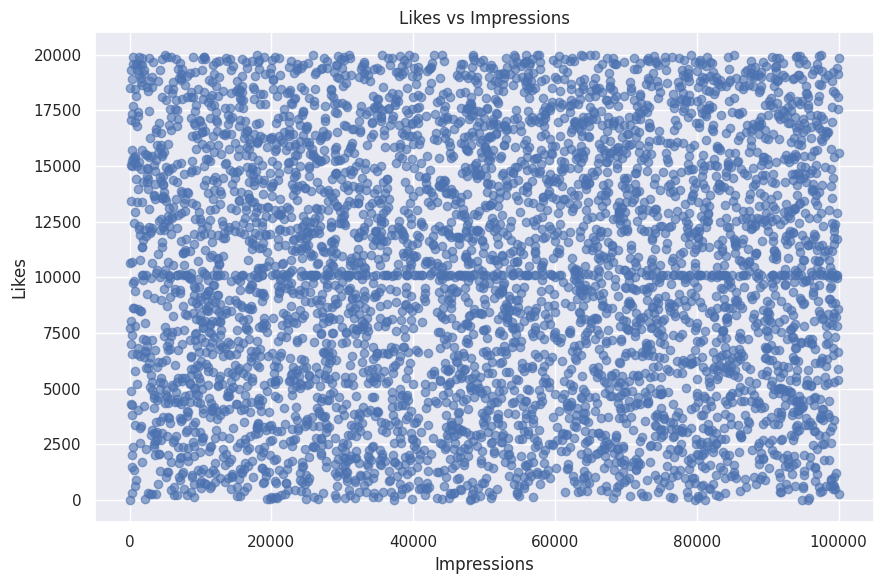

📌 Observations plotted: 5,000


In [27]:
# ❤️ Likes vs Impressions

if likes_col and impressions_col:
    plot_data = df_w[[likes_col, impressions_col]].dropna()

    plt.figure(figsize=(9, 6))
    plt.scatter(plot_data[impressions_col], plot_data[likes_col], alpha=0.6)
    plt.title('Likes vs Impressions')
    plt.xlabel('Impressions')
    plt.ylabel('Likes')
    plt.tight_layout()
    plt.show()

    print(f"📌 Observations plotted: {len(plot_data):,}")
else:
    print("ℹ️ Likes/impressions comparison skipped because the dataset does not contain both fields.")


## 6.2 Matplotlib — Line Chart: Daily Engagement Trend

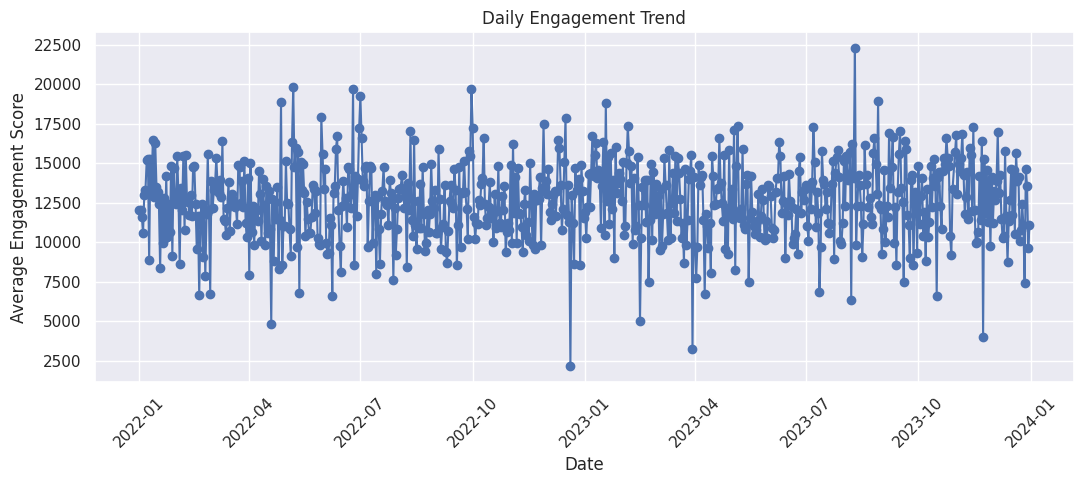

In [28]:
# 📅 Daily Engagement Trend

if date_col and date_col in df_w.columns and 'engagement_score' in df_w.columns:
    daily_engagement = (
        df_w.assign(_date=pd.to_datetime(df_w[date_col], errors='coerce').dt.date)
            .dropna(subset=['_date'])
            .groupby('_date')['engagement_score']
            .mean()
            .reset_index()
    )

    if not daily_engagement.empty:
        plt.figure(figsize=(11, 5))
        plt.plot(
            daily_engagement['_date'],
            daily_engagement['engagement_score'],
            marker='o'
        )
        plt.title('Daily Engagement Trend')
        plt.xlabel('Date')
        plt.ylabel('Average Engagement Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("ℹ️ No valid dates were available for the daily trend.")
else:
    print("ℹ️ Daily trend skipped because no valid date field was detected.")


## 6.3 Matplotlib — Bar Chart: Posts by Category

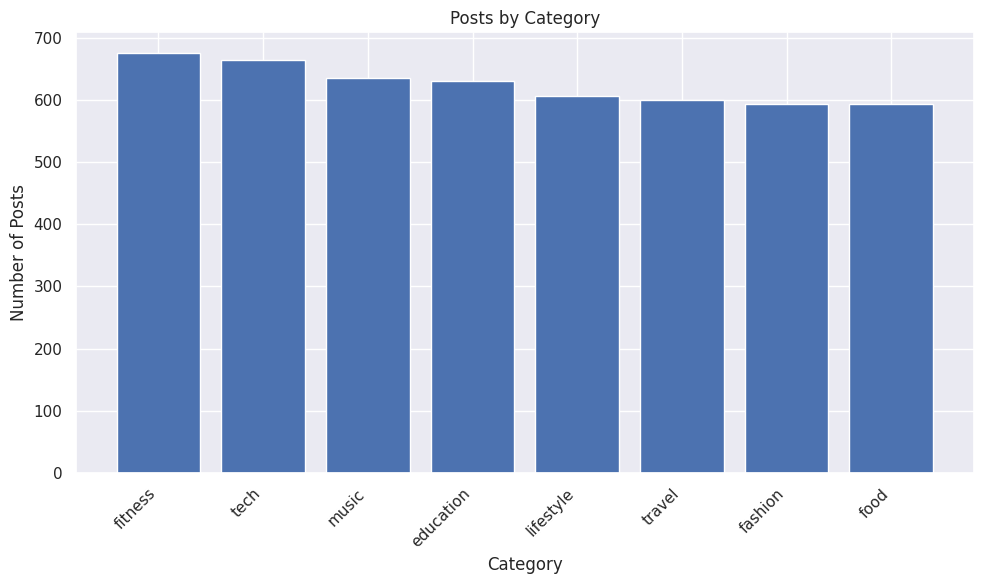

In [29]:
if category_col := column_map.get('category'):
    category_counts = df_w[category_col].value_counts().head(15)
    plt.figure(figsize=(10,6))
    plt.bar(category_counts.index.astype(str), category_counts.values)
    plt.title('Posts by Category')
    plt.xlabel('Category')
    plt.ylabel('Number of Posts')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Category column not detected.")


## 6.4 Matplotlib — Pie Chart: Gender Distribution

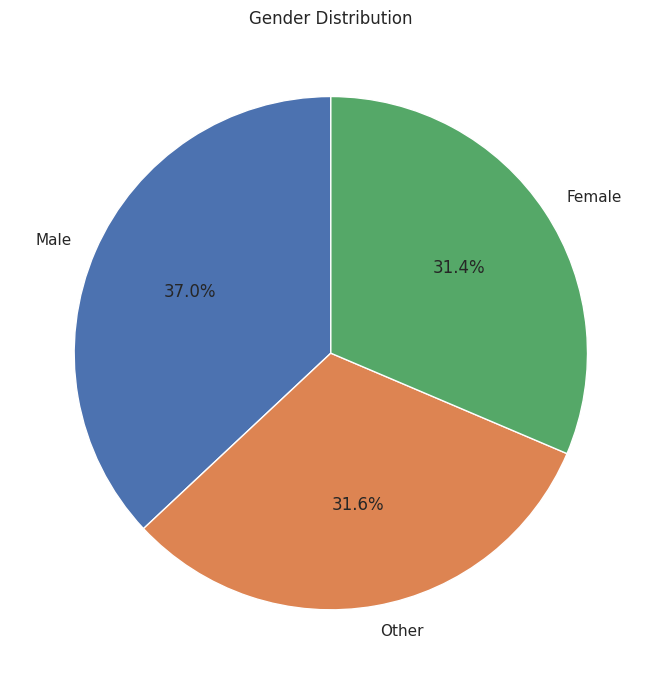

In [30]:
if gender_col and gender_col in df_w.columns:
    gender_counts = df_w[gender_col].value_counts()
    plt.figure(figsize=(7,7))
    plt.pie(gender_counts.values, labels=gender_counts.index.astype(str),
            autopct='%1.1f%%', startangle=90)
    plt.title('Gender Distribution')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Gender column not detected.")


## 6.5 Matplotlib — Histogram: Age

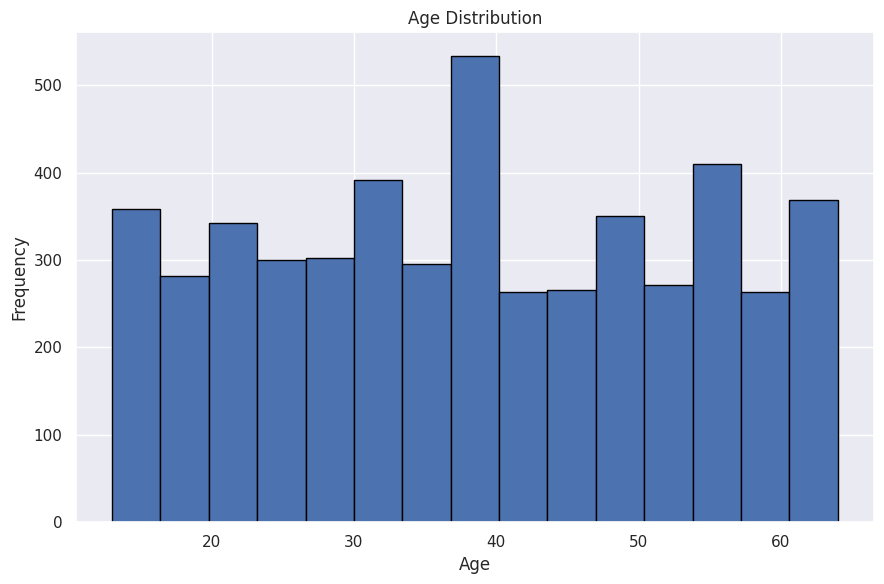

In [31]:
age_col = column_map.get('age')

if age_col and age_col in df_w.columns:
    plt.figure(figsize=(9,6))
    plt.hist(df_w[age_col].dropna(), bins=15, edgecolor='black')
    plt.title('Age Distribution')
    plt.xlabel('Age')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Age column not detected.")


## 6.6 Matplotlib — Box Plot: Engagement Rate

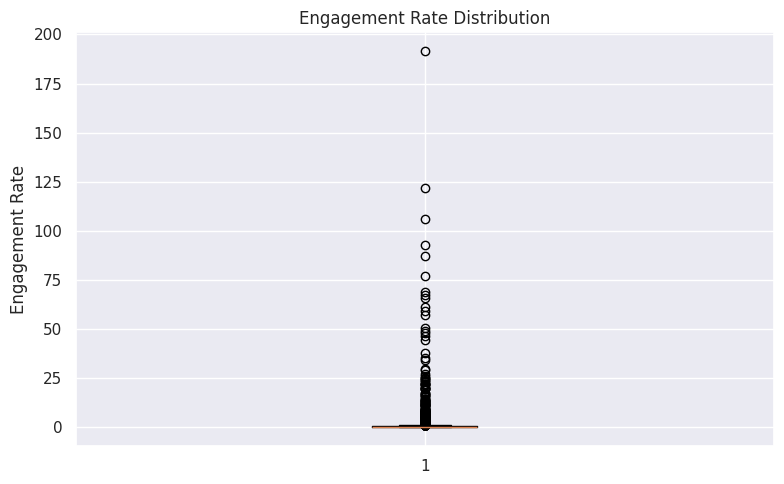

In [32]:
eng_rate_col = column_map.get('engagement_rate')

if eng_rate_col and eng_rate_col in df_w.columns:
    plt.figure(figsize=(8,5))
    plt.boxplot(df_w[eng_rate_col].dropna(), vert=True)
    plt.title('Engagement Rate Distribution')
    plt.ylabel('Engagement Rate')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Engagement rate column not detected.")


## 6.7 Seaborn — Count Plot: Post Type

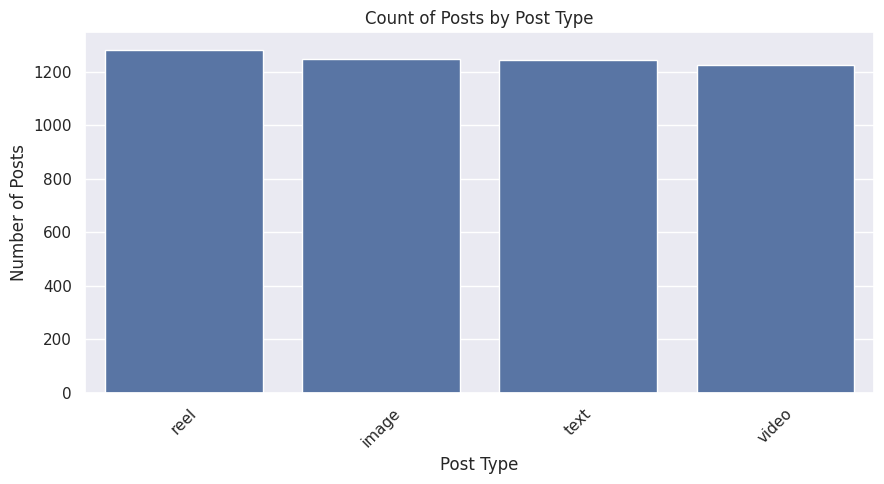

In [33]:
if post_type_col and post_type_col in df_w.columns:
    plt.figure(figsize=(9,5))
    order = df_w[post_type_col].value_counts().index
    sns.countplot(data=df_w, x=post_type_col, order=order)
    plt.title('Count of Posts by Post Type')
    plt.xlabel('Post Type')
    plt.ylabel('Number of Posts')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Post type column not detected.")


## 6.8 Seaborn — Bar Plot: Average Likes by Category

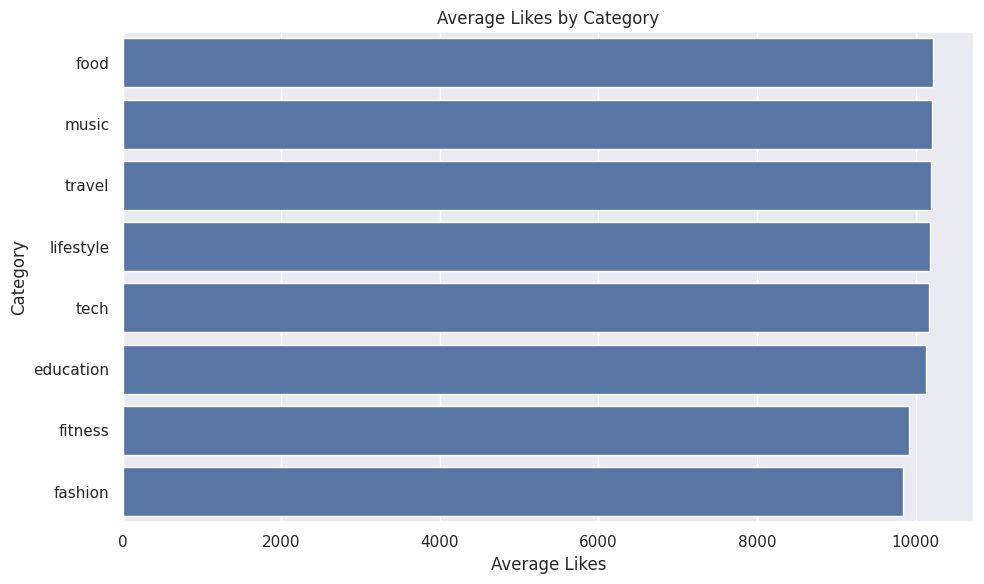

In [34]:
if category_col and likes_col:
    avg_likes_category = (
        df_w.groupby(category_col)[likes_col]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    plt.figure(figsize=(10,6))
    sns.barplot(data=avg_likes_category, x=likes_col, y=category_col)
    plt.title('Average Likes by Category')
    plt.xlabel('Average Likes')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Category/likes columns not detected.")


## 6.9 Seaborn — Violin Plot: Followers vs Sentiment

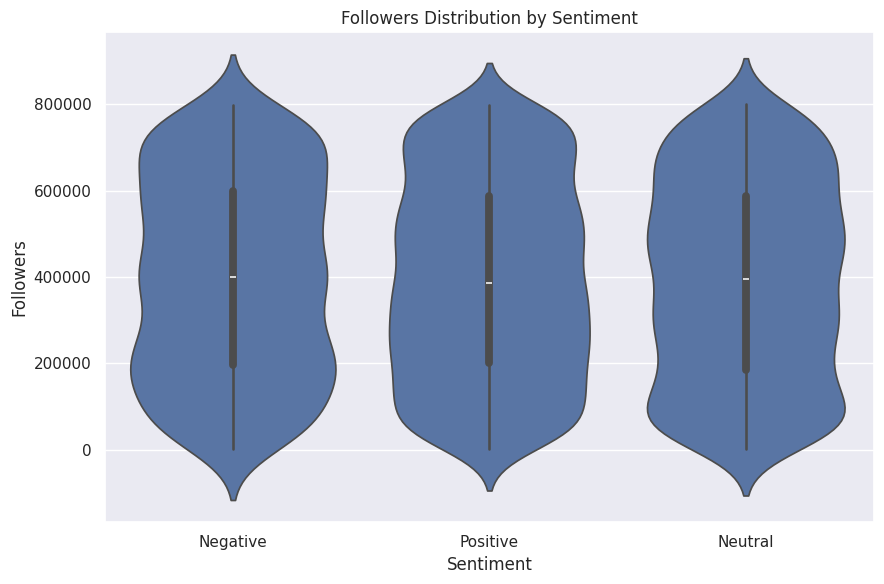

In [35]:
followers_col = column_map.get('followers')

if followers_col and sentiment_col and followers_col in df_w.columns and sentiment_col in df_w.columns:
    plt.figure(figsize=(9,6))
    sns.violinplot(data=df_w, x=sentiment_col, y=followers_col)
    plt.title('Followers Distribution by Sentiment')
    plt.xlabel('Sentiment')
    plt.ylabel('Followers')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Followers/sentiment columns not detected.")


## 6.10 Seaborn — Pair Plot: Numeric Features

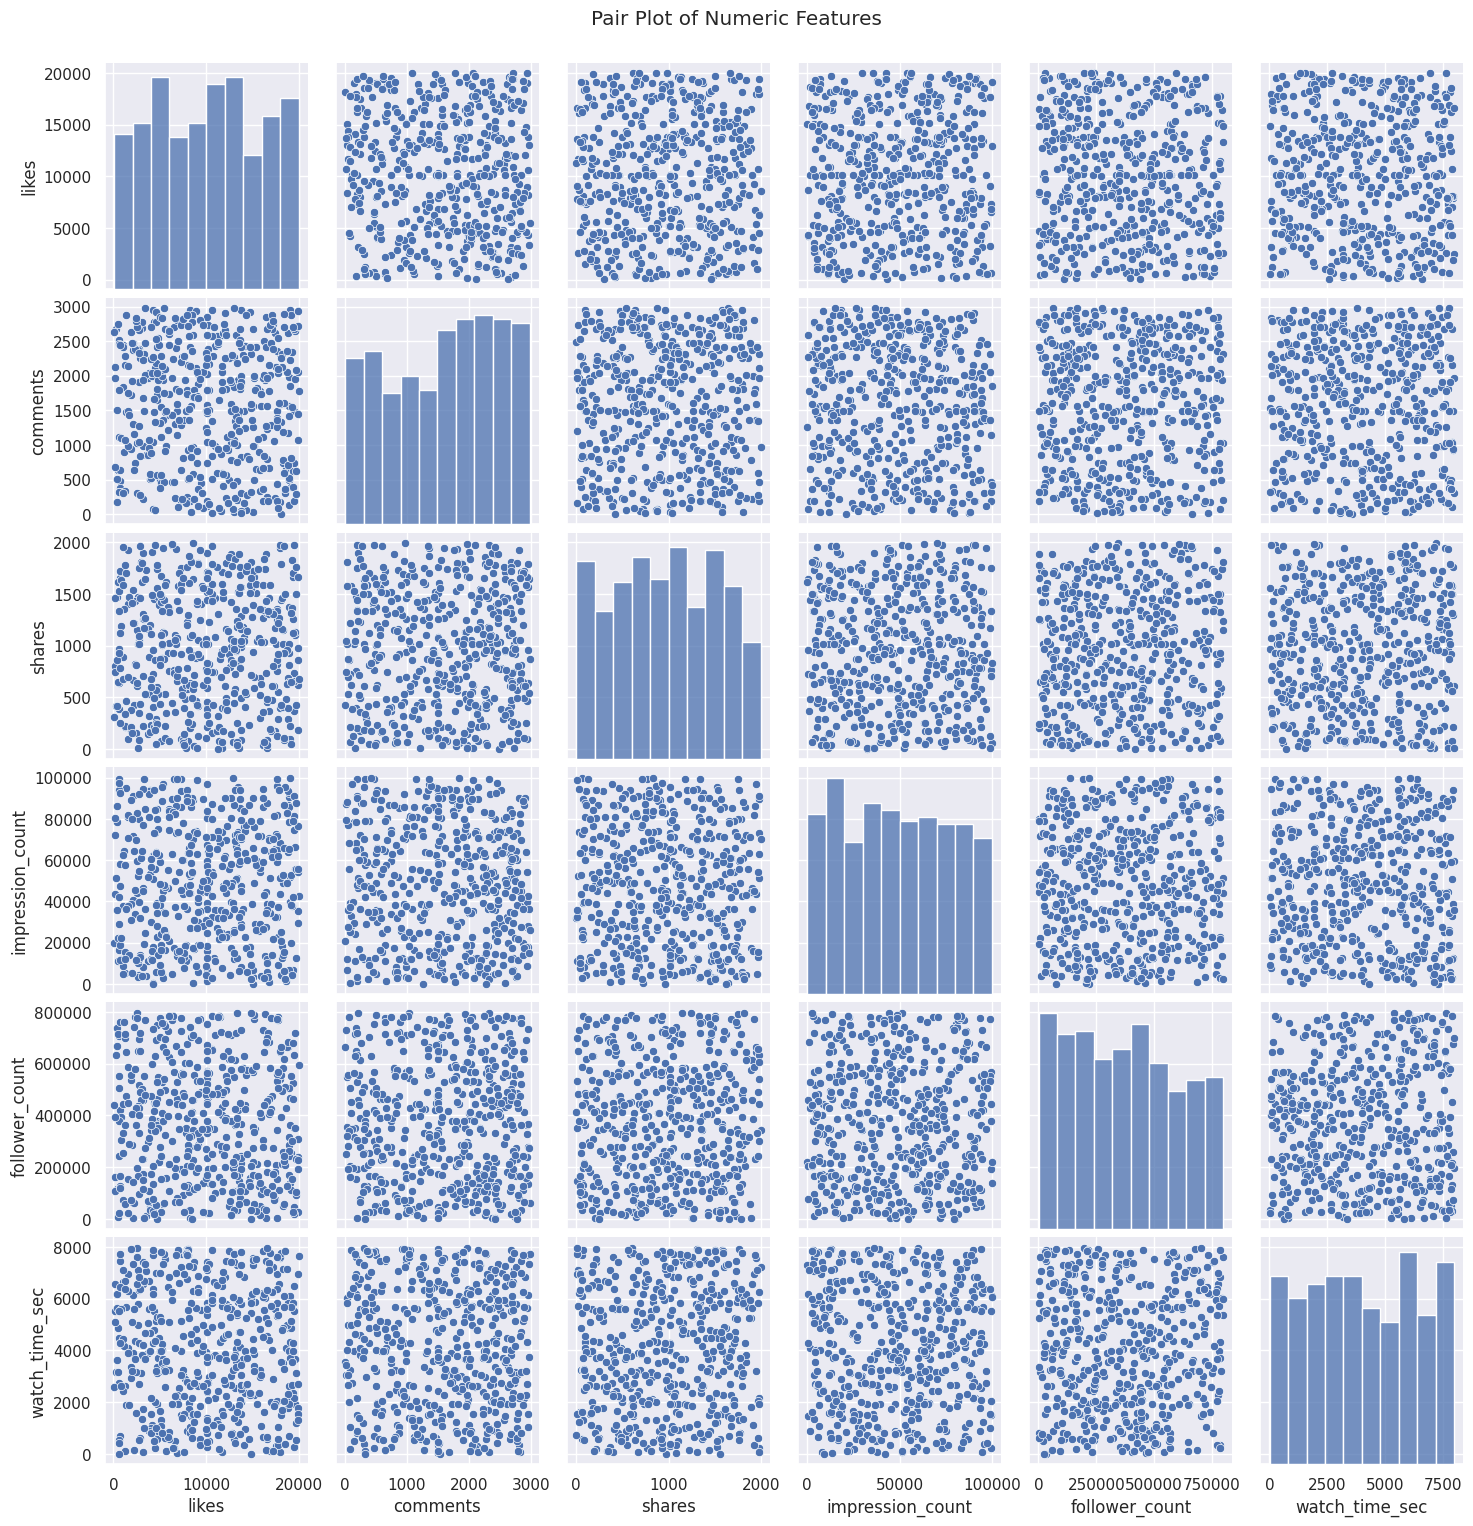

In [36]:
pair_fields = [c for c in [
    likes_col, column_map.get('comments'), column_map.get('shares'),
    impressions_col, followers_col, column_map.get('watch_time'),
    eng_rate_col
] if c and c in df_w.columns]

pair_fields = list(dict.fromkeys(pair_fields))[:6]

if len(pair_fields) >= 2:
    pair_sample = df_w[pair_fields].dropna().sample(
        min(500, len(df_w[pair_fields].dropna())),
        random_state=42
    )
    sns.pairplot(pair_sample)
    plt.suptitle('Pair Plot of Numeric Features', y=1.02)
    plt.show()
else:
    print("⚠️ At least two numeric analysis fields are required.")


## 6.11 Seaborn — Heatmap: Correlation Matrix

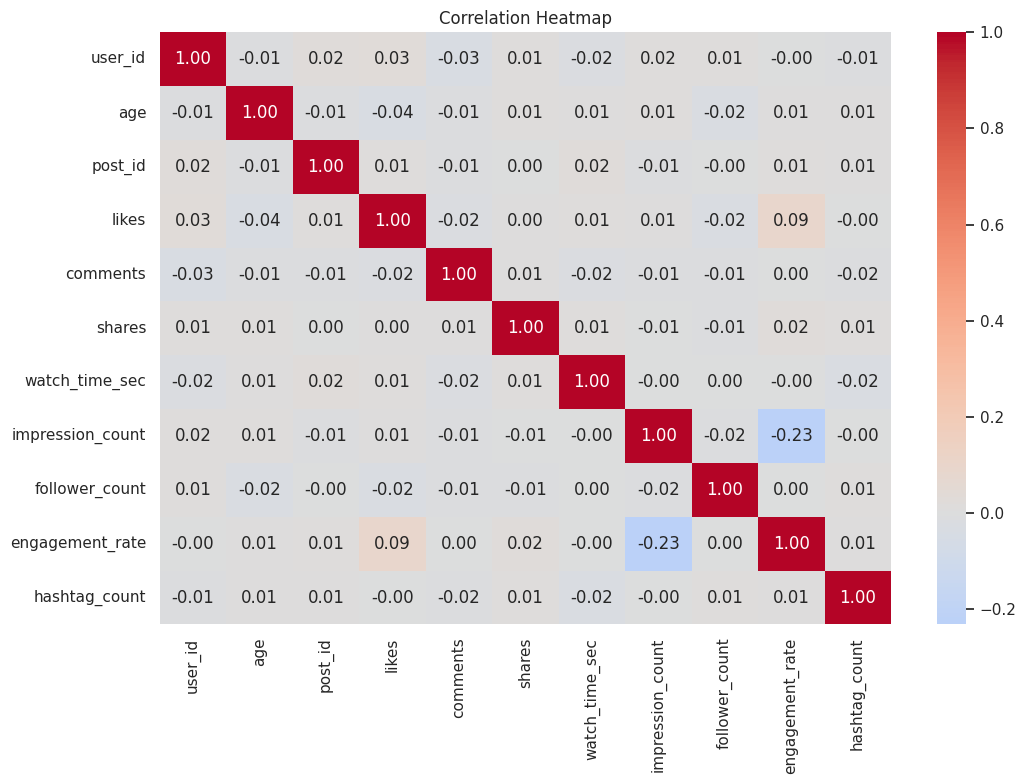

In [37]:
if not correlation_matrix.empty:
    plt.figure(figsize=(11,8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Correlation matrix unavailable.")


## 6.12 Seaborn — Swarm Plot: Engagement vs Device

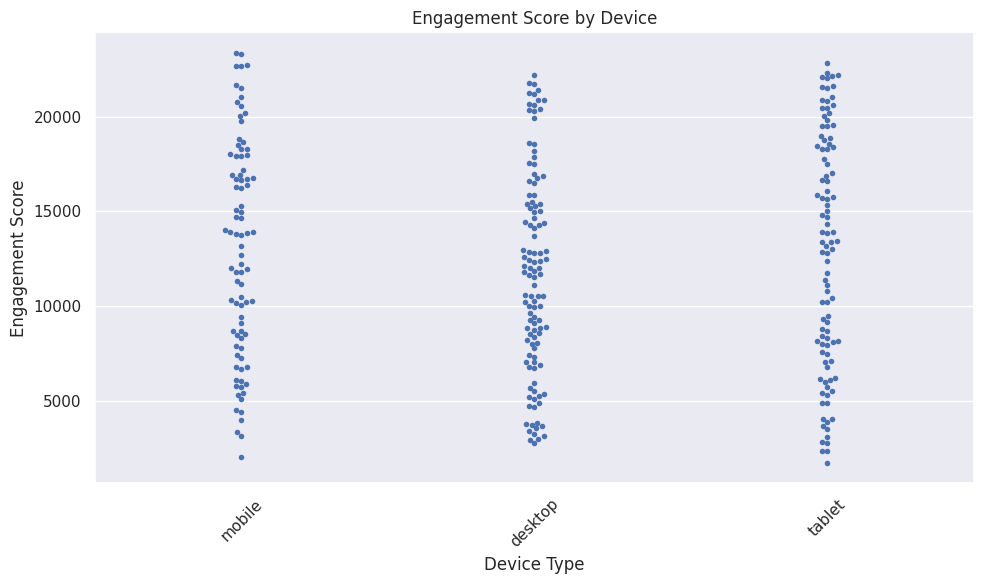

In [38]:
device_col = column_map.get('device')

if device_col and device_col in df_w.columns and 'engagement_score' in df_w.columns:
    swarm_data = df_w[[device_col, 'engagement_score']].dropna().copy()
    # Limit to 300 observations for readable plotting
    swarm_data = swarm_data.sample(min(300, len(swarm_data)), random_state=42)

    plt.figure(figsize=(10,6))
    sns.swarmplot(data=swarm_data, x=device_col, y='engagement_score', size=4)
    plt.title('Engagement Score by Device')
    plt.xlabel('Device Type')
    plt.ylabel('Engagement Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Device/engagement fields not detected.")


## 6.13 Plotly — Interactive Line Chart

In [39]:
if date_col and date_col in df_w.columns and 'engagement_score' in df_w.columns:
    plotly_daily = (
        df_w.assign(_date=pd.to_datetime(df_w[date_col], errors='coerce').dt.date)
            .dropna(subset=['_date'])
            .groupby('_date')['engagement_score']
            .mean()
            .reset_index()
    )
    fig = px.line(
        plotly_daily, x='_date', y='engagement_score',
        title='Interactive Daily Engagement Trend',
        markers=True
    )
    fig.update_layout(xaxis_title='Date', yaxis_title='Average Engagement Score')
    fig.show()
else:
    print("⚠️ Date/engagement fields not detected.")


## 6.14 Plotly — Interactive Bar Chart

In [40]:
if category_col and 'engagement_score' in df_w.columns:
    plotly_bar = (
        df_w.groupby(category_col)['engagement_score']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    fig = px.bar(
        plotly_bar, x=category_col, y='engagement_score',
        title='Interactive Average Engagement by Category',
        text_auto='.2f'
    )
    fig.show()
else:
    print("⚠️ Category/engagement fields not detected.")


## 6.15 Plotly — Interactive Bubble/Scatter Chart

In [41]:
# 🫧 Interactive Likes vs Impressions Bubble Chart

if likes_col and impressions_col:
    bubble_data = df_w[[likes_col, impressions_col]].dropna().copy()
    bubble_data['engagement_score'] = df_w.loc[bubble_data.index, 'engagement_score']

    if eng_rate_col and eng_rate_col in df_w.columns:
        bubble_data[eng_rate_col] = df_w.loc[bubble_data.index, eng_rate_col]

        fig = px.scatter(
            bubble_data,
            x=impressions_col,
            y=likes_col,
            size='engagement_score',
            color=eng_rate_col,
            hover_data=bubble_data.columns,
            title='Interactive Likes vs Impressions Bubble Chart'
        )
    else:
        fig = px.scatter(
            bubble_data,
            x=impressions_col,
            y=likes_col,
            size='engagement_score',
            hover_data=bubble_data.columns,
            title='Interactive Likes vs Impressions Bubble Chart'
        )

    fig.show()
else:
    print("ℹ️ Interactive likes/impressions chart skipped because both fields are not available.")


# 💡 FINAL INSIGHTS

The following sections calculate the requested business/user/behavior/sentiment insights directly from the cleaned dataset.

## 7.1 Content Performance — Which Post Types Have the Highest Engagement?

In [42]:
if post_type_col and 'engagement_score' in df_w.columns:
    post_type_perf = (
        df_w.groupby(post_type_col)
        .agg(
            posts=('engagement_score', 'size'),
            avg_engagement=('engagement_score', 'mean'),
            median_engagement=('engagement_score', 'median')
        )
        .sort_values('avg_engagement', ascending=False)
    )
    display(post_type_perf.round(2))
    if not post_type_perf.empty:
        top = post_type_perf.index[0]
        print(f"📌 Highest average engagement post type: {top}")
else:
    print("⚠️ Required fields not detected.")


,posts,avg_engagement,median_engagement
post_type,,,
video,1225,"12,664.59","12,634.00"
image,1247,"12,649.39","12,881.50"
text,1245,"12,613.24","12,457.00"
reel,1283,"12,524.03","12,279.00"


📌 Highest average engagement post type: video


## 7.2 Content Performance — Best-Performing Content Category

In [43]:
if category_col and 'engagement_score' in df_w.columns:
    category_perf = (
        df_w.groupby(category_col)
        .agg(
            posts=('engagement_score', 'size'),
            avg_engagement=('engagement_score', 'mean'),
            avg_likes=(likes_col, 'mean') if likes_col else ('engagement_score', 'mean')
        )
        .sort_values('avg_engagement', ascending=False)
    )
    display(category_perf.round(2))
    if not category_perf.empty:
        print(f"📌 Highest average-engagement category: {category_perf.index[0]}")
else:
    print("⚠️ Category field not detected.")


,posts,avg_engagement,avg_likes
post_category,,,
music,635,"12,788.55","10,205.75"
food,593,"12,739.20","10,225.52"
tech,665,"12,686.49","10,171.57"
travel,600,"12,650.56","10,196.30"
lifestyle,607,"12,639.54","10,180.56"
education,631,"12,578.27","10,126.49"
fitness,675,"12,457.79","9,914.60"
fashion,594,"12,356.42","9,843.36"


📌 Highest average-engagement category: music


## 7.3 Content Performance — Countries with Highest Average Engagement Rate

In [44]:
if country_col and eng_rate_col:
    country_perf = (
        df_w.groupby(country_col)[eng_rate_col]
        .agg(['count', 'mean', 'median'])
        .query('count >= 1')
        .sort_values('mean', ascending=False)
    )
    display(country_perf.head(15).round(4))
    if not country_perf.empty:
        print(f"📌 Highest average engagement-rate country in the dataset: {country_perf.index[0]}")
else:
    print("⚠️ Country/engagement-rate fields not detected.")


,count,mean,median
country,,,
Brazil,504,1.54,0.25
Australia,493,1.32,0.27
France,496,1.15,0.24
UAE,503,1.11,0.27
Canada,513,0.92,0.26
UK,493,0.85,0.24
Japan,472,0.77,0.26
Germany,490,0.76,0.27
India,535,0.66,0.25


📌 Highest average engagement-rate country in the dataset: Brazil


## 7.4 User Trends — How Age Affects Engagement

In [45]:
if age_col and 'engagement_score' in df_w.columns:
    age_analysis = (
        df_w.groupby(age_col)['engagement_score']
        .agg(['count', 'mean', 'median'])
        .sort_index()
    )
    display(age_analysis.head(30).round(2))

    valid_age = df_w[[age_col, 'engagement_score']].dropna()
    if len(valid_age) >= 2:
        corr_age = valid_age[age_col].corr(valid_age['engagement_score'])
        print(f"📌 Pearson correlation between age and engagement score: {corr_age:.4f}")
else:
    print("⚠️ Age/engagement fields not detected.")


,count,mean,median
age,,,
13.00,82,"12,718.04","12,269.00"
14.00,102,"13,469.01","13,376.50"
15.00,86,"12,830.11","12,533.00"
16.00,88,"12,235.70","12,245.50"
17.00,90,"14,156.45","14,950.00"
18.00,98,"12,474.94","12,168.00"
19.00,94,"11,867.06","11,789.50"
20.00,81,"13,075.78","14,224.00"
21.00,87,"12,447.35","12,288.00"


📌 Pearson correlation between age and engagement score: -0.0355


## 7.5 User Trends — Performance Difference for Verified Accounts

In [46]:
verified_col = column_map.get('verified')

if verified_col and 'engagement_score' in df_w.columns:
    # Standardize common true/false representations
    def normalize_verified(x):
        if pd.isna(x):
            return 'Unknown'
        s = str(x).strip().lower()
        if s in ['true','1','yes','y','verified']:
            return 'Verified'
        if s in ['false','0','no','n','not verified','unverified']:
            return 'Not Verified'
        return str(x).strip().title()

    verified_temp = df_w.copy()
    verified_temp['verified_group'] = verified_temp[verified_col].apply(normalize_verified)

    verified_perf = (
        verified_temp.groupby('verified_group')['engagement_score']
        .agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False)
    )
    display(verified_perf.round(2))
else:
    print("⚠️ Verified/engagement fields not detected.")


,count,mean,median
verified_group,,,
Not Verified,4517,"12,644.31","12,600.00"
Verified,483,"12,309.28","11,931.00"


## 7.6 Behavioral Insights — Best Time of Day for Impressions

In [47]:
# 🕐 Best Time of Day for Impressions

df_w['_hour'] = np.nan

# Prefer a genuine datetime field and extract its hour.
if date_col and date_col in df_w.columns:
    parsed_datetime = pd.to_datetime(df_w[date_col], errors='coerce')
    df_w['_hour'] = parsed_datetime.dt.hour

# If a separate time field exists, use it where possible.
if time_col and time_col in df_w.columns:
    parsed_time = pd.to_datetime(df_w[time_col].astype(str), errors='coerce')
    extracted_hours = parsed_time.dt.hour
    df_w['_hour'] = extracted_hours.fillna(df_w['_hour'])

if impressions_col and df_w['_hour'].notna().any():
    hourly_impressions = (
        df_w.dropna(subset=['_hour', impressions_col])
        .groupby('_hour')[impressions_col]
        .agg(['count', 'mean', 'median'])
        .sort_values('mean', ascending=False)
    )

    display(hourly_impressions.round(2))

    if not hourly_impressions.empty:
        best_hour = hourly_impressions.index[0]
        print(f"📌 Highest average impressions in the dataset: {int(best_hour):02d}:00")
else:
    print("ℹ️ Posting-time analysis skipped because a usable time/date or impressions field was unavailable.")


,count,mean,median
_hour,,,
0,5000,"50,013.73","49,934.50"


📌 Highest average impressions in the dataset: 00:00


## 7.7 Behavioral Insights — Device Type Impact on Watch Time

In [48]:
# 📱 Device vs Watch Time

if device_col and watch_col and device_col in df_w.columns and watch_col in df_w.columns:
    device_watch = (
        df_w.dropna(subset=[device_col, watch_col])
        .groupby(device_col)[watch_col]
        .agg(['count', 'mean', 'median', 'sum'])
        .sort_values('mean', ascending=False)
    )

    display(device_watch.round(2))

    if not device_watch.empty:
        print("📌 Average watch-time comparison by device completed.")
else:
    print("ℹ️ Device/watch-time analysis skipped because the required fields are not present.")


,count,mean,median,sum
device_type,,,,
mobile,1684,"4,087.83","4,111.00",6883907
tablet,1658,"3,979.74","4,072.00",6598403
desktop,1658,"3,974.79","3,922.00",6590206


📌 Average watch-time comparison by device completed.


## 7.8 Sentiment Analysis — Which Sentiment Performs Best?

In [49]:
if sentiment_col and 'engagement_score' in df_w.columns:
    sentiment_perf = (
        df_w.groupby(sentiment_col)
        .agg(
            posts=('engagement_score','size'),
            avg_engagement=('engagement_score','mean'),
            median_engagement=('engagement_score','median'),
            avg_likes=(likes_col,'mean') if likes_col else ('engagement_score','mean')
        )
        .sort_values('avg_engagement', ascending=False)
    )
    display(sentiment_perf.round(2))
    if not sentiment_perf.empty:
        print(f"📌 Highest average engagement sentiment: {sentiment_perf.index[0]}")
else:
    print("⚠️ Sentiment/engagement fields not detected.")


,posts,avg_engagement,median_engagement,avg_likes
sentiment,,,,
Negative,960,"12,731.50","12,578.50","10,208.10"
Positive,2513,"12,665.80","12,691.50","10,180.06"
Neutral,1527,"12,448.16","12,244.00","9,923.19"


📌 Highest average engagement sentiment: Negative


## 7.9 Sentiment Analysis — Negative & Neutral Post Behavior

In [50]:
if sentiment_col:
    sentiment_cols = [c for c in [
        likes_col, column_map.get('comments'), column_map.get('shares'),
        impressions_col, watch_col, eng_rate_col, 'engagement_score'
    ] if c and c in df_w.columns]

    negative_neutral = (
        df_w[df_w[sentiment_col].isin(['Negative','Neutral'])]
        .groupby(sentiment_col)[sentiment_cols]
        .agg(['count','mean','median'])
    )
    display(negative_neutral.round(2))

    print("📌 Interpretation table above compares the behavioral metrics for Negative vs Neutral posts.")
else:
    print("⚠️ Sentiment column not detected.")


likes                     comments                   shares  \
          count      mean    median    count     mean   median  count   
sentiment                                                               
Negative    960 10,208.10 10,105.50      960 1,516.09 1,497.00    960   
Neutral    1527  9,923.19  9,914.00     1527 1,528.40 1,497.00   1527   

                            impression_count                      \
              mean   median            count      mean    median   
sentiment                                                          
Negative  1,007.31 1,012.00              960 50,191.96 50,349.00   
Neutral     996.57 1,012.00             1527 49,515.97 48,980.00   

          watch_time_sec                   engagement_rate              \
                   count     mean   median           count mean median   
sentiment                                                                
Negative             960 4,054.64 4,077.50             960 1.04   0.26   
Neutral             1527 4,031.82 4,053.00            1527 0.99   0.25   

          engagement_score                      
                     count      mean    median  
sentiment                                       
Negative               960 12,731.50 12,578.50  
Neutral               1527 12,448.16 12,244.00

📌 Interpretation table above compares the behavioral metrics for Negative vs Neutral posts.


# 📝 FINAL SUMMARY TABLE

## Requested Insights — Automated Dataset Findings

In [55]:
summary_rows = []

def safe_top(group_col, metric):
    if (
        group_col
        and metric
        and group_col in df_w.columns
        and metric in df_w.columns
    ):
        s = (
            df_w.groupby(group_col)[metric]
            .mean()
            .dropna()
            .sort_values(ascending=False)
        )
        return s.index[0] if not s.empty else 'N/A'

    return 'N/A'


# 📊 Content Performance
summary_rows.append([
    'Highest-engagement post type',
    safe_top(post_type_col, 'engagement_score')
])

summary_rows.append([
    'Best-performing category',
    safe_top(category_col, 'engagement_score')
])

summary_rows.append([
    'Highest-average-engagement country',
    safe_top(country_col, eng_rate_col)
])


# 💭 Sentiment Analysis
summary_rows.append([
    'Highest-engagement sentiment',
    safe_top(sentiment_col, 'engagement_score')
])


# 📱 Device Analysis
summary_rows.append([
    'Highest-watch-time device',
    safe_top(device_col, watch_col)
])


# ⏰ Best Time of Day for Impressions
if (
    impressions_col
    and impressions_col in df_w.columns
    and '_hour' in df_w.columns
    and df_w['_hour'].notna().any()
):
    hour_avg = (
        df_w.groupby('_hour')[impressions_col]
        .mean()
        .dropna()
    )

    if not hour_avg.empty:
        best_hour = int(hour_avg.idxmax())
        best_hour_text = f"{best_hour:02d}:00"
    else:
        best_hour_text = 'N/A'
else:
    best_hour_text = 'N/A'


summary_rows.append([
    'Best time of day for impressions',
    best_hour_text
])


# 📋 Final Summary Table
final_summary = pd.DataFrame(
    summary_rows,
    columns=['Analysis Area', 'Dataset Finding']
)

display(final_summary)

,Analysis Area,Dataset Finding
0,Highest-engagement post type,video
1,Best-performing category,music
2,Highest-average-engagement country,Brazil
3,Highest-engagement sentiment,Negative
4,Highest-watch-time device,mobile
5,Best time of day for impressions,00:00


## 🏁 Conclusion
Overall, this assignment demonstrates a complete **Python data analytics workflow** for social-media data. It combines data cleaning, feature engineering, exploratory analysis, statistical techniques, visualization, and interactive analysis to convert raw data into meaningful information.

The project demonstrates how Python can be used to support **data-driven content analysis, audience understanding, engagement analysis, and business decision-making** while considering the quality and limitations of the underlying dataset.
